# Entrega 2 — Procesamiento de datos y modelo base

**Universidad del Norte — Machine Learning**

Martínez Pulido, Valerie · Basto Martínez, Abrahan · Esguerra Fernández, Rubén

Continúa el [análisis exploratorio](https://rubenesg.github.io/Machine_learning/) y el
diagnóstico de variables. Aquí se **procesan los datos** aplicando las decisiones que ese
diagnóstico respaldó con evidencia, y se entrenan los **modelos lineales regularizados** del
curso: regresión logística con penalización Ridge y Lasso para la tarea de clasificación, y
regresión Ridge y Lasso para la tarea de regresión.

**Problema.** El conjunto ofrece `churn_probability`, una variable **continua** acotada en
[0,11; 0,50]. Se aborda en sus dos formas: como **regresión** sobre el puntaje continuo y como
**clasificación binaria** tras binarizarlo, para predecir qué clientes tienen alto riesgo de fuga
a partir de su perfil, uso de canales digitales, satisfacción y actividad transaccional.

**Datos.** COFINFAD — *Colombian Fintech Financial Analytics Dataset*, público en Mendeley Data,
[DOI 10.17632/mhb4zn3258.1](https://data.mendeley.com/datasets/mhb4zn3258/1), licencia CC BY 4.0.
Se esperan `customer_data.csv` y `transactions_data.csv` en la carpeta `datos/` junto a este
cuaderno.

---

## 1. Librerías y carga de las dos tablas

In [1]:
import os
import sys
import time
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold,
                                     cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, recall_score,
                             precision_score, f1_score, accuracy_score, classification_report,
                             confusion_matrix, r2_score, mean_absolute_error,
                             mean_squared_error)
from IPython.display import Markdown, display

AZUL = '#1f3a5f'
PAL = ['#1f3a5f', '#3d78bf', '#7fb0e0', '#a8cbec']
sns.set_theme(style='whitegrid')
sns.set_palette(sns.color_palette(PAL))
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

SEED = 42
T_INICIO = time.time()

In [2]:
# La carpeta de datos se resuelve de forma relativa al cuaderno, para que sea reproducible en
# cualquier maquina sin editar rutas absolutas.
CANDIDATAS = [Path('datos'), Path('..') / 'datos', Path('data')]
CARPETA_DATOS = next((p for p in CANDIDATAS if (p / 'customer_data.csv').exists()), None)
if CARPETA_DATOS is None:
    raise FileNotFoundError(
        'No se encontro customer_data.csv. Descargue el conjunto COFINFAD desde '
        'https://data.mendeley.com/datasets/mhb4zn3258/1 y ubique customer_data.csv y '
        'transactions_data.csv en una carpeta "datos/" junto a este cuaderno.')

clientes = pd.read_csv(CARPETA_DATOS / 'customer_data.csv')
tx = pd.read_csv(CARPETA_DATOS / 'transactions_data.csv', parse_dates=['date'])

print(f'carpeta de datos : {CARPETA_DATOS.resolve()}')
print(f'clientes         : {clientes.shape[0]:,} filas x {clientes.shape[1]} columnas')
print(f'transacciones    : {tx.shape[0]:,} filas x {tx.shape[1]} columnas')

carpeta de datos : D:\Ruben\universidad\machine_learning\entrega 2\datos
clientes         : 48,723 filas x 54 columnas
transacciones    : 3,159,157 filas x 4 columnas


---

## 2. Limpieza de la tabla de transacciones

El diagnóstico encontró filas exactamente duplicadas, ningún monto menor o igual a cero, ninguna
fecha nula y correspondencia total entre ambas tablas. La celda siguiente **vuelve a verificar
cada una** de esas afirmaciones sobre los datos cargados, en lugar de darlas por buenas.

In [3]:
n_dup = int(tx.duplicated().sum())
n_montos_no_positivos = int((tx['amount'] <= 0).sum())
n_fechas_nulas = int(tx['date'].isna().sum())
n_huerfanos = int((~tx['customer_id'].isin(clientes['customer_id'])).sum())
n_sin_tx = int((~clientes['customer_id'].isin(tx['customer_id'])).sum())

print(f'filas exactamente duplicadas : {n_dup:,}  ({n_dup / len(tx) * 100:.3f} % del total)')
print(f'montos <= 0                  : {n_montos_no_positivos:,}')
print(f'fechas nulas                 : {n_fechas_nulas:,}')
print(f'transacciones huerfanas      : {n_huerfanos:,}')
print(f'clientes sin transacciones   : {n_sin_tx:,}')
print(f'cobertura temporal           : {tx["date"].min():%Y-%m-%d} a {tx["date"].max():%Y-%m-%d}')

antes = len(tx)
tx = tx.drop_duplicates()
print(f'\ntransacciones: {antes:,}  ->  {len(tx):,}   (eliminadas {antes - len(tx)})')

filas exactamente duplicadas : 102  (0.003 % del total)
montos <= 0                  : 0
fechas nulas                 : 0
transacciones huerfanas      : 0
clientes sin transacciones   : 0
cobertura temporal           : 2023-01-04 a 2023-12-29



transacciones: 3,159,157  ->  3,159,055   (eliminadas 102)


### 2.1 Variables derivadas del detalle transaccional

Se construyen para **evaluar** si el comportamiento transaccional predice la fuga. El diagnóstico
apuntaba a que su aporte es nulo, pero se calculan igualmente porque su exclusión debe quedar
justificada con evidencia y no por omisión. En las secciones 9 y 10 se mide su contribución.

In [4]:
fecha_corte = tx['date'].max()

base = tx.groupby('customer_id').agg(
    n_tx=('amount', 'size'), monto_total=('amount', 'sum'),
    monto_medio=('amount', 'mean'), monto_mediano=('amount', 'median'),
    monto_desv=('amount', 'std'), ultima_tx=('date', 'max'), primera_tx=('date', 'min'))

base['recencia_dias'] = (fecha_corte - base['ultima_tx']).dt.days
base['dias_activo'] = (base['ultima_tx'] - base['primera_tx']).dt.days
base['volatilidad_monto'] = base['monto_desv'] / base['monto_medio']
base = base.drop(columns=['ultima_tx', 'primera_tx', 'monto_desv'])

tx['mes'] = tx['date'].dt.to_period('M')
meses_activos = tx.groupby('customer_id')['mes'].nunique().rename('meses_activos')

mix = pd.crosstab(tx['customer_id'], tx['type'], normalize='index').add_prefix('prop_')

VARIABLES_TX = base.join([meses_activos, mix])
COLUMNAS_TX = list(VARIABLES_TX.columns)
print(f'variables derivadas: {VARIABLES_TX.shape[1]}')
print(COLUMNAS_TX)
display(VARIABLES_TX.head())

variables derivadas: 12
['n_tx', 'monto_total', 'monto_medio', 'monto_mediano', 'recencia_dias', 'dias_activo', 'volatilidad_monto', 'meses_activos', 'prop_Deposit', 'prop_Payment', 'prop_Transfer', 'prop_Withdrawal']


,n_tx,monto_total,monto_medio,monto_mediano,recencia_dias,dias_activo,volatilidad_monto,meses_activos,prop_Deposit,prop_Payment,prop_Transfer,prop_Withdrawal
customer_id,,,,,,,,,,,,
10000617,10,60540250,"6,054,025.0000","5,755,100.0000",24,325,0.4357,7,0.1000,0.4000,0.5000,0.0000
10003212,11,23401550,"2,127,413.6364","1,879,450.0000",11,334,0.6272,7,0.0000,0.1818,0.8182,0.0000
10004554,10,35759150,"3,575,915.0000","3,278,150.0000",63,200,0.6127,4,0.1000,0.3000,0.4000,0.2000
10008981,14,21186950,"1,513,353.5714","1,147,575.0000",29,293,0.7009,9,0.0000,0.2143,0.6429,0.1429
10011329,19,11640800,"612,673.6842","514,100.0000",42,307,0.8244,9,0.0526,0.3684,0.3684,0.2105


In [5]:
df = clientes.merge(VARIABLES_TX, left_on='customer_id', right_index=True, how='left')
print(f'tabla unida: {df.shape[0]:,} filas x {df.shape[1]} columnas')

tabla unida: 48,723 filas x 66 columnas


---

## 3. Variables que se eliminan

Cada eliminación se apoya en un número obtenido sobre estos mismos datos. Todos esos números se
**recalculan en la sección 3.1**, de modo que la tabla queda respaldada por salidas de esta
ejecución y no por una cita externa.

| Columna | Evidencia | Criterio |
|---|---|---|
| `customer_id` | Llave única | Identificador |
| `active_products` | Correlación muy alta con el objetivo y escalera de paso constante entre niveles | **Fuga de información** |
| `customer_lifetime_value` | ρ de Spearman ≈ 1 con `total_tx_volume` | Segunda variable objetivo |
| `clv_segment` | Derivada de la anterior | Segunda variable objetivo |
| `average_transaction_value` | Mismos valores que `avg_tx_value` pero 0 % de coincidencia por fila | Duplicado desalineado |
| `total_transaction_volume` | Mismos valores que `total_tx_volume` pero 0 % de coincidencia por fila | Duplicado desalineado |
| `avg_daily_transactions` | r = 1,000 con `transaction_frequency` | Duplicado exacto |
| `monthly_transaction_count` | r = 1,000 con las dos anteriores | Duplicado exacto |
| `first_transaction_date`, `last_transaction_date` | Mismo número de valores distintos y rango que `first_tx` y `last_tx` | Duplicado |
| `nps_score` | r ≈ 0,92 con `satisfaction_score` | Colinealidad |
| `occupation` | 35 niveles, ninguno relevante; η² ≈ 0 | Alta cardinalidad sin señal |
| `complaint_topics`, `feature_requests` | ~50 % y ~33 % ausentes, ausencia aproximadamente aleatoria y correlación ≈ 0 con el objetivo | Faltantes sin mecanismo ni señal |
| `last_survey_date`, `first_tx`, `last_tx` | η² cercano a cero | Fechas sin señal |

**Decisión sobre las columnas booleanas.** El diagnóstico descartó la sospecha de que
`active_products` fuera su suma. Son independientes, **se conservan**, y la ablación de la
sección 9 lo confirma: quitarlas no cambia el AUC.

### 3.1 Verificación de la evidencia

Cada número citado arriba se recalcula a continuación.

In [6]:
obj = df['churn_probability']

# (a) active_products: correlacion y varianza explicada por una sola variable
r_ap = obj.corr(df['active_products'])
r2_ap = r_ap ** 2
escalera = df.groupby('active_products')['churn_probability'].agg(['count', 'mean', 'std'])
escalera['salto'] = escalera['mean'].diff()

print(f'(a) active_products  r = {r_ap:+.4f}   R2 con una sola variable = {r2_ap:.4f}')
display(escalera.round(4))
print(f'    saltos entre niveles consecutivos: '
      f'{np.round(escalera["salto"].dropna().values, 4)}')
print(f'    desviacion de los saltos: {escalera["salto"].dropna().std():.5f}')
print('    un paso constante es la firma de una regla determinista, no de una asociacion')

(a) active_products  r = -0.8760   R2 con una sola variable = 0.7673


,count,mean,std,salto
active_products,,,,
1,19576,0.3974,0.0321,NaN
2,14653,0.3478,0.0325,-0.0496
3,7197,0.2983,0.0324,-0.0495
4,4871,0.2476,0.0328,-0.0507
5,2426,0.1978,0.0323,-0.0498


    saltos entre niveles consecutivos: [-0.0496 -0.0495 -0.0507 -0.0498]
    desviacion de los saltos: 0.00057
    un paso constante es la firma de una regla determinista, no de una asociacion


In [7]:
# (b) customer_lifetime_value frente a total_tx_volume
rho_clv = df['customer_lifetime_value'].corr(df['total_tx_volume'], method='spearman')
print(f'(b) CLV vs total_tx_volume   rho de Spearman = {rho_clv:.4f}')

# (c) duplicados desalineados y exactos
pares = [('avg_tx_value', 'average_transaction_value'),
         ('total_tx_volume', 'total_transaction_volume'),
         ('transaction_frequency', 'avg_daily_transactions'),
         ('transaction_frequency', 'monthly_transaction_count')]
filas = []
for a, b in pares:
    por_fila = np.isclose(df[a], df[b], rtol=1e-6).mean() * 100
    mismos = np.isclose(np.sort(df[a].values), np.sort(df[b].values), rtol=1e-6).mean() * 100
    filas.append([f'{a} / {b}', por_fila, mismos, df[a].corr(df[b])])
print('\n(c) pares de columnas transaccionales')
display(pd.DataFrame(filas, columns=['par', 'coincide por fila (%)',
                                     'mismos valores ordenados (%)', 'r']).round(4))

(b) CLV vs total_tx_volume   rho de Spearman = 0.9843

(c) pares de columnas transaccionales


,par,coincide por fila (%),mismos valores ordenados (%),r
0,avg_tx_value / average_transaction_value,0.0021,100.0000,0.0020
1,total_tx_volume / total_transaction_volume,0.0021,100.0000,-0.0006
2,transaction_frequency / avg_daily_transactions,100.0000,100.0000,1.0000
3,transaction_frequency / monthly_transaction_count,0.0000,0.0000,1.0000


In [8]:
# (d) colinealidad satisfaccion / NPS
r_nps = df['satisfaction_score'].corr(df['nps_score'])
print(f'(d) satisfaction_score vs nps_score   r = {r_nps:.4f}')


# (e) eta cuadrado de las categoricas y fechas candidatas a eliminar
def eta2(categorica, continua):
    g = pd.DataFrame({'c': categorica.astype(str), 'y': continua}).dropna()
    media = g['y'].mean()
    entre = g.groupby('c')['y'].apply(lambda s: len(s) * (s.mean() - media) ** 2).sum()
    total = ((g['y'] - media) ** 2).sum()
    return entre / total


candidatas = ['occupation', 'last_survey_date', 'first_tx', 'last_tx']
print('\n(e) eta cuadrado frente a churn_probability')
display(pd.DataFrame({'variable': candidatas,
                      'niveles': [df[c].nunique() for c in candidatas],
                      'eta2': [eta2(df[c], obj) for c in candidatas]}).round(4))

(d) satisfaction_score vs nps_score   r = 0.9167

(e) eta cuadrado frente a churn_probability


,variable,niveles,eta2
0,occupation,35,0.0008
1,last_survey_date,365,0.0070
2,first_tx,180,0.0040
3,last_tx,174,0.0037


In [9]:
# (f) faltantes: mecanismo
print('(f) mecanismo de los valores faltantes')
falt = df.isna().sum()
falt = (falt[falt > 0].to_frame('faltantes')
        .assign(pct=lambda d: d['faltantes'] / len(df) * 100))
display(falt.round(2))

tabla = pd.crosstab(df['credit_utilization_ratio'].isna(), df['credit_card'], normalize='index')
tabla.index = ['valor presente', 'valor ausente']
print('proporcion de clientes con tarjeta, segun si falta credit_utilization_ratio:')
display(tabla.round(4))

for col in ['complaint_topics', 'feature_requests']:
    ausente = df[col].isna().astype(int)
    print(f'{col:<20} r de la ausencia con el objetivo: {ausente.corr(obj):+.4f}   '
          f'churn medio presente/ausente: {obj[ausente == 0].mean():.4f} / '
          f'{obj[ausente == 1].mean():.4f}')

(f) mecanismo de los valores faltantes


,faltantes,pct
credit_utilization_ratio,18263,37.4800
feature_requests,16115,33.0700
complaint_topics,24346,49.9700


proporcion de clientes con tarjeta, segun si falta credit_utilization_ratio:


credit_card,False,True
valor presente,0.0000,1.0000
valor ausente,1.0000,0.0000


complaint_topics     r de la ausencia con el objetivo: -0.0007   churn medio presente/ausente: 0.3430 / 0.3429
feature_requests     r de la ausencia con el objetivo: -0.0066   churn medio presente/ausente: 0.3432 / 0.3423


In [10]:
# (g) las columnas booleanas no reconstruyen active_products
BOOLEANAS = ['savings_account', 'credit_card', 'personal_loan', 'investment_account',
             'insurance_product', 'bill_payment_user', 'auto_savings_enabled']
suma_bool = df[BOOLEANAS].sum(axis=1)
print(f'(g) suma de booleanas vs active_products: '
      f'coincidencia {(suma_bool == df["active_products"]).mean() * 100:.1f} %   '
      f'r = {suma_bool.corr(df["active_products"]):+.4f}')
print('    -> son independientes; conservarlas no reintroduce la fuga')

# (h) correlacion de las derivadas transaccionales con el objetivo
corr_tx = df[COLUMNAS_TX].corrwith(obj).sort_values(key=abs, ascending=False)
print(f'\n(h) mayor correlacion en valor absoluto entre las derivadas transaccionales y el '
      f'objetivo: {corr_tx.abs().max():.4f}')
display(corr_tx.to_frame('r con churn_probability').round(4))

(g) suma de booleanas vs active_products: coincidencia 14.9 %   r = +0.0069
    -> son independientes; conservarlas no reintroduce la fuga

(h) mayor correlacion en valor absoluto entre las derivadas transaccionales y el objetivo: 0.0281


,r con churn_probability
n_tx,-0.0281
prop_Withdrawal,0.0155
dias_activo,-0.0147
monto_total,-0.0130
recencia_dias,0.0118
meses_activos,-0.0109
prop_Payment,-0.0081
prop_Transfer,-0.0077
prop_Deposit,0.0064
volatilidad_monto,-0.0025


In [11]:
COLUMNAS_A_ELIMINAR = [
    'customer_id',
    'active_products',
    'customer_lifetime_value', 'clv_segment',
    'average_transaction_value', 'total_transaction_volume',
    'avg_daily_transactions', 'monthly_transaction_count',
    'first_transaction_date', 'last_transaction_date',
    'nps_score',
    'occupation',
    'complaint_topics', 'feature_requests',
    'last_survey_date', 'first_tx', 'last_tx',
]

datos = df.drop(columns=COLUMNAS_A_ELIMINAR)
print(f'{df.shape[1]} columnas  ->  {datos.shape[1]} columnas   '
      f'(eliminadas {len(COLUMNAS_A_ELIMINAR)})')

66 columnas  ->  49 columnas   (eliminadas 17)


---

## 4. Tratamiento de los valores faltantes

La verificación (f) mostró que `credit_utilization_ratio` falta **exactamente** en los clientes
sin `credit_card`. No es un dato perdido sino un *no aplica*, y el valor correcto para esos
clientes es cero. Es una imputación por definición del dominio, no una estimación a partir de los
datos, de modo que puede aplicarse antes de partir sin introducir fuga: no usa ningún estadístico
del conjunto.

In [12]:
datos['credit_utilization_ratio'] = datos['credit_utilization_ratio'].fillna(0)
print('faltantes tras el tratamiento:', int(datos.isna().sum().sum()))

faltantes tras el tratamiento:

 0


---

## 5. Partición y definición de la variable objetivo

Binarizar `churn_probability` por su mediana exige una precaución. La mediana es un estadístico
estimado de los datos, y estimarla sobre el **conjunto completo** haría que la definición de la
etiqueta de prueba dependiera de las propias filas de prueba: fuga de información en el diseño
experimental, fácil de pasar por alto porque el estadístico parece inocuo.

El orden que lo evita es el siguiente:

1. se parte primero, sobre el objetivo **continuo**;
2. el umbral se estima **solo con entrenamiento**;
3. ese umbral, ya fijo, se aplica a ambos conjuntos.

Como consecuencia, la partición **no puede estratificarse** por la etiqueta: la etiqueta todavía
no existe cuando se parte. Se comprueba abajo que el balance resultante es prácticamente perfecto
de todos modos, porque el corte es la mediana.

In [13]:
y_continuo = datos['churn_probability']
X = datos.drop(columns=['churn_probability'])

# 1. partir primero, usando el objetivo continuo
idx_train, idx_test = train_test_split(X.index, test_size=0.2, random_state=SEED)
X_train, X_test = X.loc[idx_train], X.loc[idx_test]
y_train_cont, y_test_cont = y_continuo.loc[idx_train], y_continuo.loc[idx_test]

# 2. el umbral se estima SOLO con entrenamiento
umbral = y_train_cont.median()

# 3. se aplica, ya fijo, a ambos conjuntos
y_train = (y_train_cont > umbral).astype(int)
y_test = (y_test_cont > umbral).astype(int)

print(f'umbral estimado en entrenamiento : {umbral:.6f}')
print(f'entrenamiento : {len(X_train):,} clientes   riesgo alto {y_train.mean() * 100:.2f} %')
print(f'prueba        : {len(X_test):,} clientes   riesgo alto {y_test.mean() * 100:.2f} %')
print(f'\nX: {X.shape[0]:,} filas x {X.shape[1]} columnas (antes de codificar)')

umbral estimado en entrenamiento : 0.353972
entrenamiento : 38,978 clientes   riesgo alto 49.99 %
prueba        : 9,745 clientes   riesgo alto 49.91 %

X: 48,723 filas x 48 columnas (antes de codificar)


### 5.1 Cuánto cambia el resultado al corregir la fuga

Para no dar por supuesto el tamaño del problema, se mide directamente: se construye también la
etiqueta que resultaría del cálculo *incorrecto* —umbral sobre el conjunto completo— y se cuenta
cuántas etiquetas de prueba difieren.

In [14]:
umbral_con_fuga = y_continuo.median()          # el calculo incorrecto, solo para comparar
y_test_con_fuga = (y_test_cont > umbral_con_fuga).astype(int)
n_cambian = int((y_test != y_test_con_fuga).sum())

print(f'umbral con fuga (conjunto completo) : {umbral_con_fuga:.6f}')
print(f'umbral correcto (solo entrenamiento): {umbral:.6f}')
print(f'diferencia                          : {umbral - umbral_con_fuga:+.2e}')
print(f'etiquetas de prueba que cambian     : {n_cambian} de {len(y_test):,}')
print(f'\nvalores distintos de churn_probability: {y_continuo.nunique():,} '
      f'para {len(y_continuo):,} clientes '
      f'({len(y_continuo) / y_continuo.nunique():.0f} clientes por valor en promedio)')

umbral con fuga (conjunto completo) : 0.353972
umbral correcto (solo entrenamiento): 0.353972
diferencia                          : +0.00e+00
etiquetas de prueba que cambian     : 0 de 9,745

valores distintos de churn_probability: 1,977 para 48,723 clientes (25 clientes por valor en promedio)


### 5.2 Sensibilidad a la semilla

Con la semilla 42 ambos umbrales coinciden. No es un indulto al método: `churn_probability` toma
pocos valores distintos y muchos clientes empatan en cada uno, de modo que la mediana cae sobre un
valor repetido y la coincidencia depende del reparto concreto. Repitiendo la partición con otras
semillas se ve que el cálculo incorrecto **sí** desplaza el umbral y cambia etiquetas de prueba:
el orden debe respetarse con independencia de que una semilla particular lo haga indiferente.

In [15]:
filas = []
for semilla in [0, 1, 7, 42, 123, 2024]:
    i_tr, i_te = train_test_split(X.index, test_size=0.2, random_state=semilla)
    u = y_continuo.loc[i_tr].median()
    cambian = int(((y_continuo.loc[i_te] > umbral_con_fuga).astype(int)
                   != (y_continuo.loc[i_te] > u).astype(int)).sum())
    filas.append([semilla, u, u - umbral_con_fuga, cambian])

sensibilidad = pd.DataFrame(filas, columns=['semilla', 'umbral en entrenamiento',
                                            'diferencia con el umbral global',
                                            'etiquetas de prueba que cambian'])
display(sensibilidad)
n_afectadas = int((sensibilidad['diferencia con el umbral global'] != 0).sum())
print(f'la fuga desplaza el umbral en {n_afectadas} de las {len(sensibilidad)} semillas probadas, '
      f'y llega a cambiar hasta '
      f'{sensibilidad["etiquetas de prueba que cambian"].max()} etiquetas de prueba')

,semilla,umbral en entrenamiento,diferencia con el umbral global,etiquetas de prueba que cambian
0,0,0.3542,0.0003,18
1,1,0.3539,-0.0001,6
2,7,0.3540,0.0000,0
3,42,0.3540,0.0000,0
4,123,0.3539,-0.0001,5
5,2024,0.3538,-0.0001,16


la fuga desplaza el umbral en 4 de las 6 semillas probadas, y llega a cambiar hasta 18 etiquetas de prueba


---

## 6. Preprocesamiento dentro del `Pipeline`

La codificación de las categóricas y el escalado de las numéricas se encapsulan en un
`ColumnTransformer` que vive **dentro** del `Pipeline`. Así se ajustan únicamente con los datos de
entrenamiento de cada partición de la validación cruzada, y nunca con los de prueba. Crear las
indicadoras con `pd.get_dummies` sobre la tabla completa, en cambio, haría que las columnas
generadas dependieran de los datos de prueba; aunque eso no usa la etiqueta, el
`ColumnTransformer` evita el problema por construcción.

`drop='first'` descarta el primer nivel de cada categórica para evitar colinealidad perfecta, y
`handle_unknown='ignore'` deja el modelo a salvo de niveles que solo aparezcan en prueba.

In [16]:
def construir_preprocesador(Xd):
    """Escala las numericas y codifica las categoricas; se ajusta solo con entrenamiento."""
    numericas = Xd.select_dtypes(include=['number', 'bool']).columns.tolist()
    categoricas = [c for c in Xd.columns if c not in numericas]
    return ColumnTransformer([
        ('num', StandardScaler(), numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                              sparse_output=False), categoricas),
    ])


preprocesador = construir_preprocesador(X)
preprocesador.fit(X_train)
NOMBRES = list(preprocesador.get_feature_names_out())
N_VARIABLES = len(NOMBRES)

print(f'numericas y booleanas : {len(preprocesador.transformers_[0][2])}')
print(f'categoricas           : {len(preprocesador.transformers_[1][2])}')
print(f'  {preprocesador.transformers_[1][2]}')
print(f'variables tras codificar: {N_VARIABLES}')

numericas y booleanas : 39
categoricas           : 9
  ['gender', 'location', 'income_bracket', 'education_level', 'marital_status', 'acquisition_channel', 'customer_segment', 'feedback_sentiment', 'preferred_transaction_type']
variables tras codificar: 78


---

## 7. Clasificación: regresión logística y regularización Ridge / Lasso

La regresión logística modela $P(y=1\mid x)=\sigma(w^\top x+b)$ y se estima minimizando la
entropía cruzada. Sobre esa función objetivo se añaden los dos esquemas de regularización del
curso: Ridge ($L_2$, término $\tfrac{1}{2C}\lVert w\rVert_2^2$), que reparte el peso entre
variables correlacionadas, y Lasso ($L_1$, término $\tfrac{1}{C}\lVert w\rVert_1$), cuya geometría
lleva coeficientes exactamente a cero y actúa como selección de variables. En ambas, $C$ es el
inverso de la intensidad de la penalización: valores pequeños penalizan más.

In [17]:
cv_clasificacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_regresion = KFold(n_splits=5, shuffle=True, random_state=SEED)

modelo_base = Pipeline([
    ('preprocesado', construir_preprocesador(X)),
    ('logistica', LogisticRegression(max_iter=2000, random_state=SEED)),
])

auc_cv_base = cross_val_score(modelo_base, X_train, y_train,
                              cv=cv_clasificacion, scoring='roc_auc', n_jobs=-1)
print(f'AUC en validacion cruzada (sin regularizacion explicita): '
      f'{auc_cv_base.mean():.4f} +/- {auc_cv_base.std():.4f}')
print('por particion:', np.round(auc_cv_base, 4))

AUC en validacion cruzada (sin regularizacion explicita): 0.6821 +/- 0.0041
por particion: [0.6848 0.6817 0.6852 0.6845 0.6742]


In [18]:
VALORES_C = [0.001, 0.01, 0.1, 1, 10, 100]

filas = []
for nombre, penalizacion in [('Ridge (L2)', 'l2'), ('Lasso (L1)', 'l1')]:
    for C in VALORES_C:
        pipe = Pipeline([
            ('preprocesado', construir_preprocesador(X)),
            ('logistica', LogisticRegression(penalty=penalizacion, C=C, solver='liblinear',
                                             max_iter=2000, random_state=SEED)),
        ])
        auc = cross_val_score(pipe, X_train, y_train, cv=cv_clasificacion,
                              scoring='roc_auc', n_jobs=-1)
        pipe.fit(X_train, y_train)
        n_activas = int((pipe.named_steps['logistica'].coef_[0] != 0).sum())
        filas.append([nombre, C, auc.mean(), auc.std(), n_activas])

comparacion_clasificacion = pd.DataFrame(
    filas, columns=['regularizacion', 'C', 'AUC_medio', 'AUC_desv', 'variables_no_nulas'])
display(comparacion_clasificacion.sort_values('AUC_medio', ascending=False)
        .round(4).reset_index(drop=True))

,regularizacion,C,AUC_medio,AUC_desv,variables_no_nulas
0,Lasso (L1),0.1000,0.6824,0.0039,57
1,Ridge (L2),0.0100,0.6823,0.0038,78
2,Lasso (L1),1.0000,0.6822,0.0041,76
3,Ridge (L2),0.1000,0.6822,0.0040,78
4,Ridge (L2),1.0000,0.6821,0.0042,78
5,Lasso (L1),100.0000,0.6821,0.0042,78
6,Lasso (L1),10.0000,0.6821,0.0042,77
7,Ridge (L2),10.0000,0.6821,0.0042,78
8,Ridge (L2),100.0000,0.6821,0.0042,78
9,Lasso (L1),0.0100,0.6820,0.0038,19


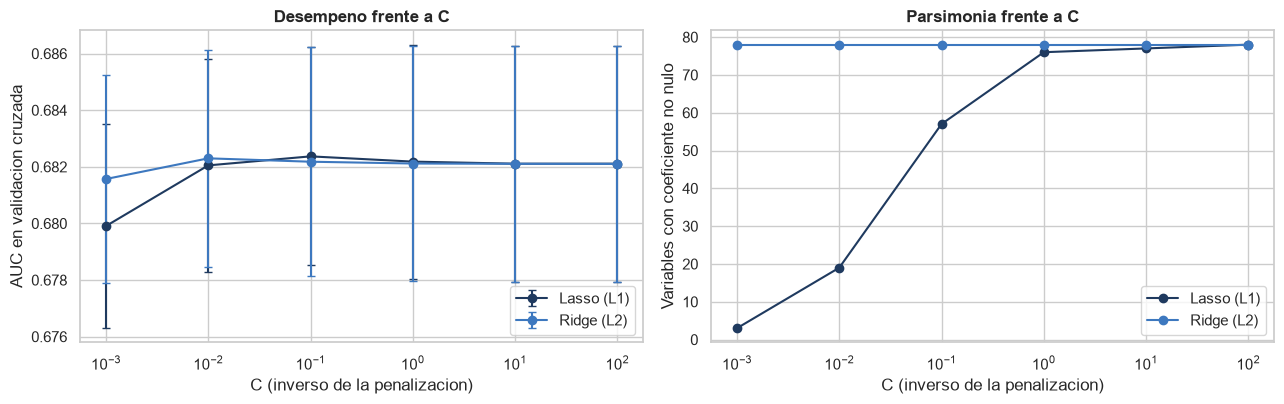

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for nombre, sub in comparacion_clasificacion.groupby('regularizacion'):
    ax[0].errorbar(sub['C'], sub['AUC_medio'], yerr=sub['AUC_desv'],
                   marker='o', capsize=3, label=nombre)
    ax[1].plot(sub['C'], sub['variables_no_nulas'], marker='o', label=nombre)
ax[0].set_xscale('log'); ax[0].set_xlabel('C (inverso de la penalizacion)')
ax[0].set_ylabel('AUC en validacion cruzada'); ax[0].set_title('Desempeno frente a C')
ax[0].legend()
ax[1].set_xscale('log'); ax[1].set_xlabel('C (inverso de la penalizacion)')
ax[1].set_ylabel('Variables con coeficiente no nulo')
ax[1].set_title('Parsimonia frente a C'); ax[1].legend()
plt.tight_layout(); plt.show()

In [20]:
malla = {'logistica__C': VALORES_C, 'logistica__penalty': ['l1', 'l2']}

busqueda = GridSearchCV(
    Pipeline([('preprocesado', construir_preprocesador(X)),
              ('logistica', LogisticRegression(solver='liblinear', max_iter=2000,
                                               random_state=SEED))]),
    malla, cv=cv_clasificacion, scoring='roc_auc', n_jobs=-1)
busqueda.fit(X_train, y_train)

modelo = busqueda.best_estimator_
MEJOR_C = busqueda.best_params_['logistica__C']
MEJOR_PENALIZACION = busqueda.best_params_['logistica__penalty']
AUC_CV = busqueda.best_score_
AUC_CV_DESV = busqueda.cv_results_['std_test_score'][busqueda.best_index_]

print('mejores parametros:', busqueda.best_params_)
print(f'AUC en validacion cruzada: {AUC_CV:.4f} +/- {AUC_CV_DESV:.4f}')

mejores parametros: {'logistica__C': 0.1, 'logistica__penalty': 'l1'}
AUC en validacion cruzada: 0.6824 +/- 0.0039


---

## 8. Regresión Ridge y Lasso sobre el objetivo continuo

`churn_probability` es continua, de modo que la tarea admite tratarse directamente como
regresión, sin binarizar. Se entrenan aquí `Ridge` y `Lasso` de
`sklearn.linear_model` —los modelos de regresión regularizada del curso— y se comparan contra
mínimos cuadrados ordinarios. El hiperparámetro es `alpha`, la intensidad de la penalización: al
contrario que `C` en la logística, valores **grandes** penalizan más.

$$\text{Ridge:}\quad \min_{w,b}\ \lVert y - Xw - b\rVert_2^2 + \alpha\lVert w\rVert_2^2$$

$$\text{Lasso:}\quad \min_{w,b}\ \tfrac{1}{2n}\lVert y - Xw - b\rVert_2^2 + \alpha\lVert w\rVert_1$$

Se reportan R², RMSE y MAE. Como el objetivo está acotado en un rango estrecho, el RMSE no es
interpretable en términos absolutos: debe leerse contra la desviación típica del objetivo, que es
el error que obtendría un modelo que predijera siempre la media. Ambas cantidades se calculan e
imprimen abajo.

In [21]:
print(f'objetivo continuo: media {y_train_cont.mean():.4f}   '
      f'desviacion {y_train_cont.std():.4f}   '
      f'rango [{y_continuo.min():.4f}, {y_continuo.max():.4f}]')

ALPHAS_RIDGE = [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]
ALPHAS_LASSO = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1]

busqueda_ridge = GridSearchCV(
    Pipeline([('preprocesado', construir_preprocesador(X)), ('ridge', Ridge())]),
    {'ridge__alpha': ALPHAS_RIDGE}, cv=cv_regresion, scoring='r2', n_jobs=-1)
busqueda_ridge.fit(X_train, y_train_cont)

busqueda_lasso = GridSearchCV(
    Pipeline([('preprocesado', construir_preprocesador(X)),
              ('lasso', Lasso(max_iter=20000, random_state=SEED))]),
    {'lasso__alpha': ALPHAS_LASSO}, cv=cv_regresion, scoring='r2', n_jobs=-1)
busqueda_lasso.fit(X_train, y_train_cont)

ALPHA_RIDGE = busqueda_ridge.best_params_['ridge__alpha']
ALPHA_LASSO = busqueda_lasso.best_params_['lasso__alpha']

print(f'Ridge: mejor alpha = {ALPHA_RIDGE:g}   '
      f'R2 en validacion cruzada = {busqueda_ridge.best_score_:.4f}')
print(f'Lasso: mejor alpha = {ALPHA_LASSO:g}   '
      f'R2 en validacion cruzada = {busqueda_lasso.best_score_:.4f}')

objetivo continuo: media 0.3429   desviacion 0.0671   rango [0.1143, 0.5006]


Ridge: mejor alpha = 1000   R2 en validacion cruzada = 0.1513
Lasso: mejor alpha = 0.0001   R2 en validacion cruzada = 0.1519


In [22]:
def curva_alpha(busqueda, clave):
    return pd.DataFrame({'alpha': np.asarray(busqueda.cv_results_[f'param_{clave}'], dtype=float),
                         'R2_medio': busqueda.cv_results_['mean_test_score'],
                         'R2_desv': busqueda.cv_results_['std_test_score']})


print('Ridge')
display(curva_alpha(busqueda_ridge, 'ridge__alpha').round(4))
print('Lasso')
display(curva_alpha(busqueda_lasso, 'lasso__alpha').round(4))

Ridge


,alpha,R2_medio,R2_desv
0,0.0100,0.1508,0.0093
1,0.1000,0.1509,0.0093
2,1.0000,0.1509,0.0093
3,10.0000,0.1509,0.0093
4,100.0000,0.1511,0.0092
5,"1,000.0000",0.1513,0.0087
6,"10,000.0000",0.1418,0.0062
7,"100,000.0000",0.0673,0.0016


Lasso


,alpha,R2_medio,R2_desv
0,0.0000,0.1512,0.0092
1,0.0001,0.1519,0.0090
2,0.0010,0.1498,0.0078
3,0.0100,0.0794,0.0021
4,0.1000,-0.0002,0.0002


### 8.1 Camino de los coeficientes

El gráfico clásico de la regularización: cómo se encogen los coeficientes al aumentar `alpha`.
En Ridge el encogimiento es continuo y ningún coeficiente llega exactamente a cero; en Lasso los
coeficientes se anulan uno a uno, lo que produce selección de variables.

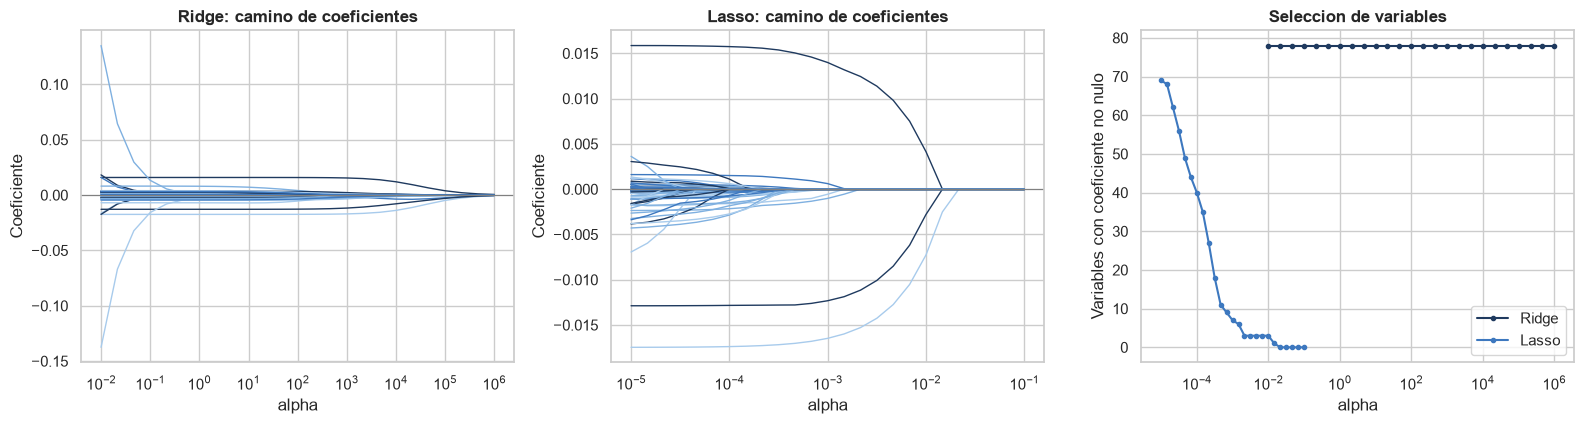

In [23]:
def camino(modelo_fn, alphas):
    coefs, activos = [], []
    for a in alphas:
        p = Pipeline([('preprocesado', construir_preprocesador(X)), ('reg', modelo_fn(a))])
        p.fit(X_train, y_train_cont)
        c = p.named_steps['reg'].coef_
        coefs.append(c)
        activos.append(int((np.abs(c) > 1e-10).sum()))
    return np.array(coefs), activos


ALPHAS_CAMINO_RIDGE = np.logspace(-2, 6, 25)
ALPHAS_CAMINO_LASSO = np.logspace(-5, -1, 25)

coefs_ridge, activos_ridge = camino(lambda a: Ridge(alpha=a), ALPHAS_CAMINO_RIDGE)
coefs_lasso, activos_lasso = camino(lambda a: Lasso(alpha=a, max_iter=20000, random_state=SEED),
                                    ALPHAS_CAMINO_LASSO)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ax[0].plot(ALPHAS_CAMINO_RIDGE, coefs_ridge, lw=1)
ax[0].set_xscale('log'); ax[0].set_xlabel('alpha'); ax[0].set_ylabel('Coeficiente')
ax[0].set_title('Ridge: camino de coeficientes'); ax[0].axhline(0, color='grey', lw=0.8)

ax[1].plot(ALPHAS_CAMINO_LASSO, coefs_lasso, lw=1)
ax[1].set_xscale('log'); ax[1].set_xlabel('alpha'); ax[1].set_ylabel('Coeficiente')
ax[1].set_title('Lasso: camino de coeficientes'); ax[1].axhline(0, color='grey', lw=0.8)

ax[2].plot(ALPHAS_CAMINO_RIDGE, activos_ridge, marker='.', label='Ridge')
ax[2].plot(ALPHAS_CAMINO_LASSO, activos_lasso, marker='.', label='Lasso')
ax[2].set_xscale('log'); ax[2].set_xlabel('alpha')
ax[2].set_ylabel('Variables con coeficiente no nulo')
ax[2].set_title('Seleccion de variables'); ax[2].legend()
plt.tight_layout(); plt.show()

### 8.2 Desempeño en prueba de los tres modelos de regresión

In [24]:
def evaluar_regresion(nombre, pipe):
    pred = pipe.predict(X_test)
    coef = pipe.named_steps[list(pipe.named_steps)[-1]].coef_
    return {'modelo': nombre,
            'R2': r2_score(y_test_cont, pred),
            'RMSE': mean_squared_error(y_test_cont, pred) ** 0.5,
            'MAE': mean_absolute_error(y_test_cont, pred),
            'variables_no_nulas': int((np.abs(coef) > 1e-10).sum())}


ols = Pipeline([('preprocesado', construir_preprocesador(X)), ('ols', LinearRegression())])
ols.fit(X_train, y_train_cont)

ridge_final = busqueda_ridge.best_estimator_
lasso_final = busqueda_lasso.best_estimator_

resultados_regresion = pd.DataFrame([
    evaluar_regresion('Minimos cuadrados (OLS)', ols),
    evaluar_regresion(f'Ridge (alpha={ALPHA_RIDGE:g})', ridge_final),
    evaluar_regresion(f'Lasso (alpha={ALPHA_LASSO:g})', lasso_final),
])
display(resultados_regresion.round(4))

R2_RIDGE = float(resultados_regresion.loc[1, 'R2'])
R2_LASSO = float(resultados_regresion.loc[2, 'R2'])
RMSE_LASSO = float(resultados_regresion.loc[2, 'RMSE'])
MAE_LASSO = float(resultados_regresion.loc[2, 'MAE'])
N_ACTIVAS_LASSO_REG = int(resultados_regresion.loc[2, 'variables_no_nulas'])
DESV_OBJETIVO = float(y_test_cont.std())
print(f'\ndesviacion tipica del objetivo en prueba: {DESV_OBJETIVO:.4f}')
print('(es el RMSE que obtendria un modelo que prediga siempre la media)')

,modelo,R2,RMSE,MAE,variables_no_nulas
0,Minimos cuadrados (OLS),0.1499,0.0617,0.0507,78
1,Ridge (alpha=1000),0.1509,0.0617,0.0507,78
2,Lasso (alpha=0.0001),0.1511,0.0617,0.0507,40



desviacion tipica del objetivo en prueba: 0.0669
(es el RMSE que obtendria un modelo que prediga siempre la media)


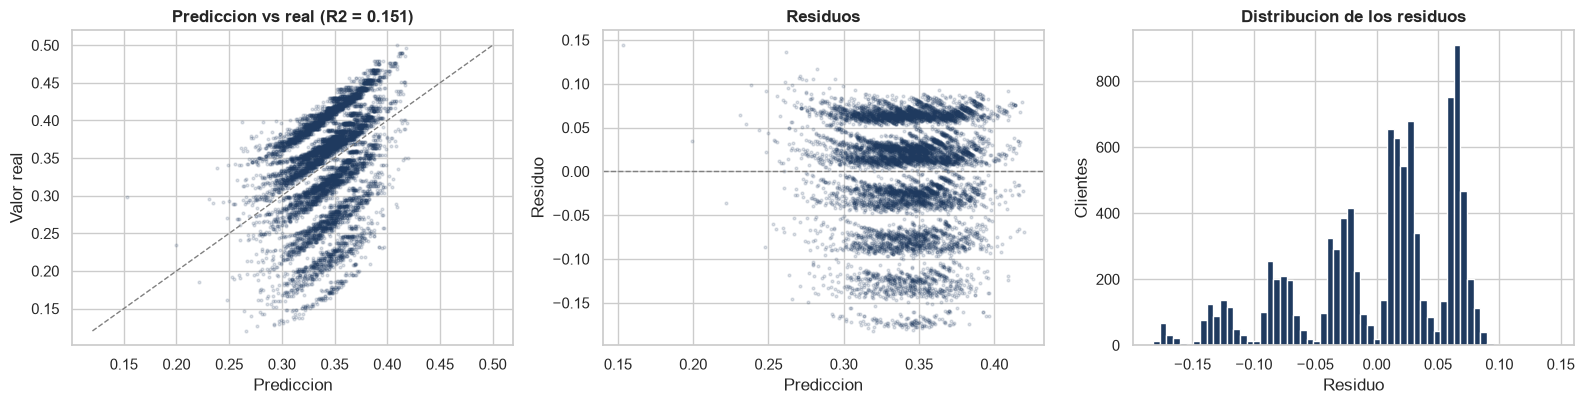

In [25]:
pred_lasso = lasso_final.predict(X_test)
residuos = y_test_cont - pred_lasso

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].scatter(pred_lasso, y_test_cont, s=4, alpha=0.15, color=AZUL)
lim = [min(pred_lasso.min(), y_test_cont.min()), max(pred_lasso.max(), y_test_cont.max())]
ax[0].plot(lim, lim, '--', color='grey', lw=1)
ax[0].set_xlabel('Prediccion'); ax[0].set_ylabel('Valor real')
ax[0].set_title(f'Prediccion vs real (R2 = {R2_LASSO:.3f})')

ax[1].scatter(pred_lasso, residuos, s=4, alpha=0.15, color=AZUL)
ax[1].axhline(0, color='grey', lw=1, ls='--')
ax[1].set_xlabel('Prediccion'); ax[1].set_ylabel('Residuo')
ax[1].set_title('Residuos')

ax[2].hist(residuos, bins=60, color=AZUL)
ax[2].set_xlabel('Residuo'); ax[2].set_ylabel('Clientes')
ax[2].set_title('Distribucion de los residuos')
plt.tight_layout(); plt.show()

---

## 9. Cuantificación de la fuga de información

La afirmación central del trabajo es que `churn_probability` fue construida a partir de
`active_products`. El experimento de ablación la pone a prueba en las **dos** tareas: se reentrena
el mismo modelo sobre distintos subconjuntos de variables y se compara el desempeño.

In [26]:
X_con_fuga = df.drop(columns=[c for c in COLUMNAS_A_ELIMINAR if c != 'active_products']
                     + ['churn_probability'])
X_con_fuga['credit_utilization_ratio'] = X_con_fuga['credit_utilization_ratio'].fillna(0)

ESCENARIOS = [
    ('Todas las variables (incluye active_products)', X_con_fuga),
    ('Sin active_products', X),
    ('Sin active_products ni columnas booleanas', X.drop(columns=BOOLEANAS)),
    ('Solo variables transaccionales derivadas', X[COLUMNAS_TX]),
    ('Solo demografia y satisfaccion', X.drop(columns=COLUMNAS_TX)),
]

filas = []
for nombre, Xi in ESCENARIOS:
    n_vars = construir_preprocesador(Xi).fit_transform(Xi.loc[idx_train]).shape[1]

    clf = Pipeline([('preprocesado', construir_preprocesador(Xi)),
                    ('logistica', LogisticRegression(max_iter=2000, random_state=SEED))])
    auc = cross_val_score(clf, Xi.loc[idx_train], y_train,
                          cv=cv_clasificacion, scoring='roc_auc', n_jobs=-1)

    reg = Pipeline([('preprocesado', construir_preprocesador(Xi)),
                    ('ridge', Ridge(alpha=ALPHA_RIDGE))])
    r2 = cross_val_score(reg, Xi.loc[idx_train], y_train_cont,
                         cv=cv_regresion, scoring='r2', n_jobs=-1)

    filas.append([nombre, n_vars, auc.mean(), r2.mean()])

ablacion = pd.DataFrame(filas, columns=['subconjunto de variables', 'n_variables',
                                        'AUC (clasificacion)', 'R2 (regresion Ridge)'])
display(ablacion.round(4))

AUC_CON_FUGA = float(ablacion.loc[0, 'AUC (clasificacion)'])
AUC_SIN_FUGA = float(ablacion.loc[1, 'AUC (clasificacion)'])
AUC_SIN_BOOL = float(ablacion.loc[2, 'AUC (clasificacion)'])
AUC_SOLO_TX = float(ablacion.loc[3, 'AUC (clasificacion)'])
R2_CON_FUGA = float(ablacion.loc[0, 'R2 (regresion Ridge)'])
R2_SIN_FUGA = float(ablacion.loc[1, 'R2 (regresion Ridge)'])

,subconjunto de variables,n_variables,AUC (clasificacion),R2 (regresion Ridge)
0,Todas las variables (incluye active_products),79,0.9736,0.9211
1,Sin active_products,78,0.6821,0.1513
2,Sin active_products ni columnas booleanas,71,0.6821,0.1514
3,Solo variables transaccionales derivadas,12,0.5016,0.0007
4,Solo demografia y satisfaccion,66,0.6816,0.1507


**Lectura.** La regresión hace el diagnóstico más nítido que la clasificación. Al binarizar se
descarta información y el AUC comprime la diferencia; sobre el objetivo continuo, en cambio, el R²
mide directamente qué fracción de la varianza de la etiqueta reproduce cada conjunto de variables.
Si una sola columna explica la mayor parte de esa varianza, la etiqueta no es un fenómeno a
predecir sino una función de esa columna. Ese contraste solo es visible al abordar la tarea en su
forma continua.

---

## 10. ¿Aportan las variables transaccionales?

Se entrena el modelo seleccionado con y sin las variables derivadas del detalle de transacciones.
La diferencia mide su contribución real, en las dos tareas.

In [27]:
filas = []
for nombre, Xi in [('Con variables transaccionales', X),
                   ('Sin variables transaccionales', X.drop(columns=COLUMNAS_TX))]:
    clf = Pipeline([('preprocesado', construir_preprocesador(Xi)),
                    ('logistica', LogisticRegression(penalty=MEJOR_PENALIZACION, C=MEJOR_C,
                                                     solver='liblinear', max_iter=2000,
                                                     random_state=SEED))])
    auc = cross_val_score(clf, Xi.loc[idx_train], y_train,
                          cv=cv_clasificacion, scoring='roc_auc', n_jobs=-1)
    reg = Pipeline([('preprocesado', construir_preprocesador(Xi)),
                    ('ridge', Ridge(alpha=ALPHA_RIDGE))])
    r2 = cross_val_score(reg, Xi.loc[idx_train], y_train_cont,
                         cv=cv_regresion, scoring='r2', n_jobs=-1)
    filas.append([nombre, Xi.shape[1], auc.mean(), auc.std(), r2.mean()])

aporte_tx = pd.DataFrame(filas, columns=['conjunto', 'n_columnas', 'AUC_medio', 'AUC_desv',
                                         'R2_medio'])
display(aporte_tx.round(4))

DIFERENCIA_TX = float(aporte_tx.loc[0, 'AUC_medio'] - aporte_tx.loc[1, 'AUC_medio'])
DESV_PARTICIONES = float(aporte_tx.loc[0, 'AUC_desv'])
print(f'\ndiferencia de AUC: {DIFERENCIA_TX:+.4f}   '
      f'desviacion entre particiones: {DESV_PARTICIONES:.4f}')
print('la diferencia es menor que el ruido entre particiones'
      if abs(DIFERENCIA_TX) < DESV_PARTICIONES else
      'la diferencia supera el ruido entre particiones')

,conjunto,n_columnas,AUC_medio,AUC_desv,R2_medio
0,Con variables transaccionales,48,0.6824,0.0039,0.1513
1,Sin variables transaccionales,36,0.6818,0.0033,0.1507



diferencia de AUC: +0.0006   desviacion entre particiones: 0.0039
la diferencia es menor que el ruido entre particiones


---

## 11. Evaluación sobre el conjunto de prueba

El conjunto de prueba no intervino en ninguna etapa del ajuste: ni en la estimación del umbral, ni
en el escalado, ni en la codificación, ni en la selección de hiperparámetros.

### 11.1 Referencia no paramétrica: k vecinos más cercanos

Antes de dar por bueno el modelo lineal conviene comprobar que no está dejando estructura sin
capturar. Un clasificador de $k$ vecinos más cercanos no impone forma funcional alguna, de modo
que si hubiera relaciones no lineales fuertes debería superarlo.

In [28]:
filas = []
for k in [10, 25, 50, 100, 200]:
    knn = Pipeline([('preprocesado', construir_preprocesador(X)),
                    ('knn', KNeighborsClassifier(n_neighbors=k))])
    auc = cross_val_score(knn, X_train, y_train, cv=cv_clasificacion,
                          scoring='roc_auc', n_jobs=-1)
    filas.append([k, auc.mean(), auc.std()])

comparacion_knn = pd.DataFrame(filas, columns=['k', 'AUC_medio', 'AUC_desv'])
display(comparacion_knn.round(4))

AUC_KNN = float(comparacion_knn['AUC_medio'].max())
MEJOR_K = int(comparacion_knn.loc[comparacion_knn['AUC_medio'].idxmax(), 'k'])
print(f'\nmejor KNN: k = {MEJOR_K}, AUC = {AUC_KNN:.4f}   '
      f'frente a {AUC_CV:.4f} de la logistica regularizada')

,k,AUC_medio,AUC_desv
0,10,0.5956,0.0025
1,25,0.6234,0.0066
2,50,0.6400,0.0072
3,100,0.6549,0.0060
4,200,0.6645,0.0035



mejor KNN: k = 200, AUC = 0.6645   frente a 0.6824 de la logistica regularizada


### 11.2 Modelo seleccionado

In [29]:
proba = modelo.predict_proba(X_test)[:, 1]
pred = modelo.predict(X_test)

AUC_TEST = roc_auc_score(y_test, proba)
RECALL_TEST = recall_score(y_test, pred)
PRECISION_TEST = precision_score(y_test, pred)
F1_TEST = f1_score(y_test, pred)
EXACTITUD_TEST = accuracy_score(y_test, pred)

print(f'AUC       : {AUC_TEST:.4f}')
print(f'Exactitud : {EXACTITUD_TEST:.4f}')
print(f'Recall    : {RECALL_TEST:.4f}')
print(f'Precision : {PRECISION_TEST:.4f}')
print(f'F1        : {F1_TEST:.4f}')
print()
print(classification_report(y_test, pred, target_names=['Riesgo bajo', 'Riesgo alto']))

AUC       : 0.6832
Exactitud : 0.6360
Recall    : 0.6515
Precision : 0.6311
F1        : 0.6412

              precision    recall  f1-score   support

 Riesgo bajo       0.64      0.62      0.63      4881
 Riesgo alto       0.63      0.65      0.64      4864

    accuracy                           0.64      9745
   macro avg       0.64      0.64      0.64      9745
weighted avg       0.64      0.64      0.64      9745



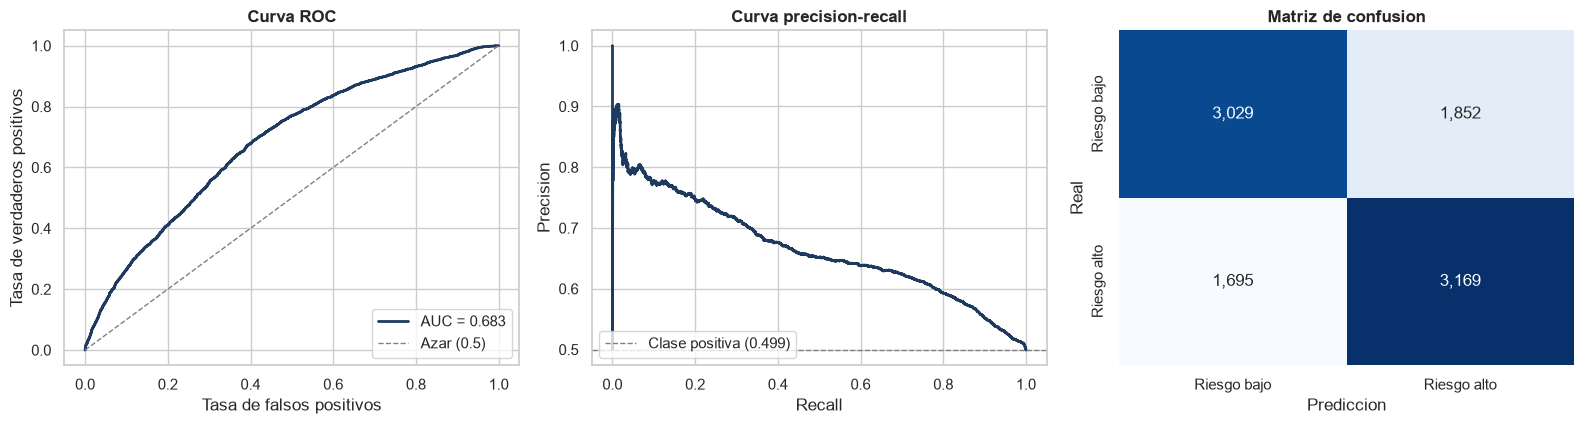

In [30]:
fpr, tpr, _ = roc_curve(y_test, proba)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

ax[0].plot(fpr, tpr, color=AZUL, lw=2, label=f'AUC = {AUC_TEST:.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', lw=1, label='Azar (0.5)')
ax[0].set_xlabel('Tasa de falsos positivos'); ax[0].set_ylabel('Tasa de verdaderos positivos')
ax[0].set_title('Curva ROC'); ax[0].legend(loc='lower right')

prec, rec, _ = precision_recall_curve(y_test, proba)
ax[1].plot(rec, prec, color=AZUL, lw=2)
ax[1].axhline(y_test.mean(), ls='--', color='grey', lw=1,
              label=f'Clase positiva ({y_test.mean():.3f})')
ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
ax[1].set_title('Curva precision-recall'); ax[1].legend(loc='lower left')

cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax[2],
            xticklabels=['Riesgo bajo', 'Riesgo alto'],
            yticklabels=['Riesgo bajo', 'Riesgo alto'])
ax[2].set_xlabel('Prediccion'); ax[2].set_ylabel('Real'); ax[2].set_title('Matriz de confusion')

plt.tight_layout(); plt.show()

### 11.3 Variables que sostienen el modelo

Los coeficientes están en escala estandarizada, por lo que su magnitud es comparable entre
variables. Se contrastan los de la logística con los de la regresión Lasso sobre el objetivo
continuo: si ambas tareas señalan las mismas variables, la lectura es robusta y no un artefacto de
haber binarizado.

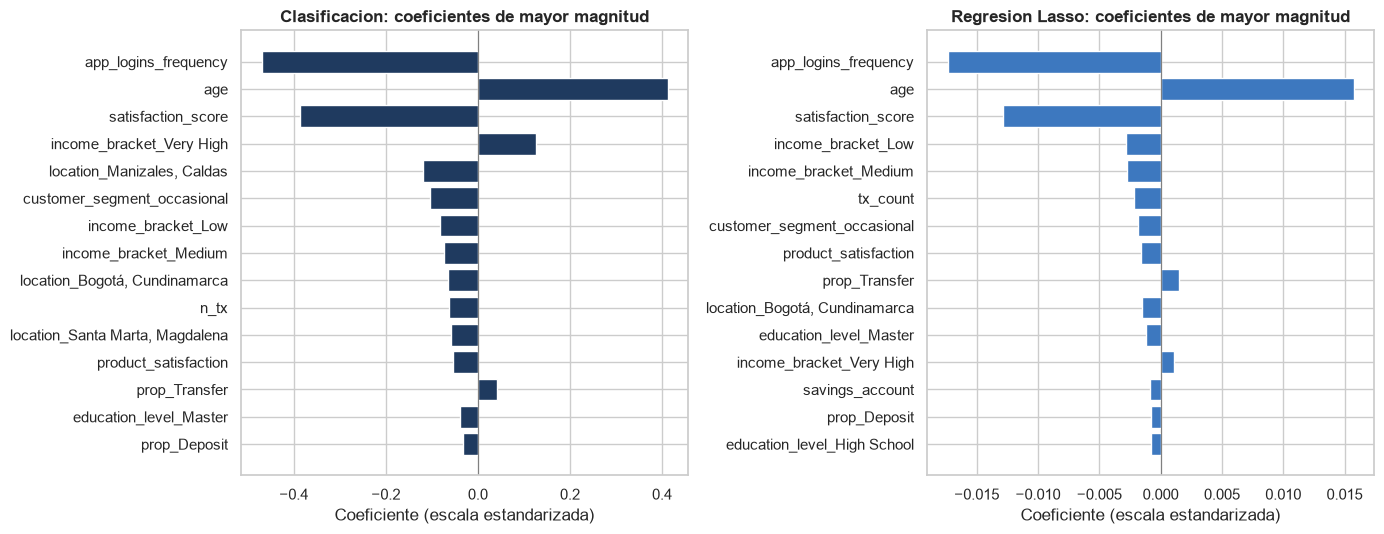

clasificacion  : 57 de 78 variables no nulas
regresion Lasso: 40 de 78 variables no nulas


,clasificacion (logistica),regresion (Lasso)
app_logins_frequency,-0.4701,-0.0174
age,0.4123,0.0157
satisfaction_score,-0.3861,-0.0128
income_bracket_Very High,0.1269,0.0011
"location_Manizales, Caldas",-0.1201,-0.0000
customer_segment_occasional,-0.1034,-0.0018
income_bracket_Low,-0.0831,-0.0029
income_bracket_Medium,-0.0728,-0.0027
"location_Bogotá, Cundinamarca",-0.0655,-0.0015
n_tx,-0.0627,-0.0000


In [31]:
coef_clasificacion = pd.Series(modelo.named_steps['logistica'].coef_[0], index=NOMBRES)
coef_regresion = pd.Series(lasso_final.named_steps['lasso'].coef_, index=NOMBRES)

N_ACTIVAS_CLASIFICACION = int((coef_clasificacion != 0).sum())
top = coef_clasificacion.reindex(
    coef_clasificacion.abs().sort_values(ascending=False).index).head(15)
top_reg = coef_regresion.reindex(coef_regresion.abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].barh([n.split('__')[-1] for n in top.index[::-1]], top.values[::-1], color=AZUL)
ax[0].axvline(0, color='grey', lw=0.8)
ax[0].set_title('Clasificacion: coeficientes de mayor magnitud')
ax[0].set_xlabel('Coeficiente (escala estandarizada)')

ax[1].barh([n.split('__')[-1] for n in top_reg.index[::-1]], top_reg.values[::-1], color='#3d78bf')
ax[1].axvline(0, color='grey', lw=0.8)
ax[1].set_title('Regresion Lasso: coeficientes de mayor magnitud')
ax[1].set_xlabel('Coeficiente (escala estandarizada)')
plt.tight_layout(); plt.show()

print(f'clasificacion  : {N_ACTIVAS_CLASIFICACION} de {N_VARIABLES} variables no nulas')
print(f'regresion Lasso: {N_ACTIVAS_LASSO_REG} de {N_VARIABLES} variables no nulas')

TRES_PRINCIPALES = [n.split('__')[-1] for n in top.index[:3]]
comparacion_coef = pd.DataFrame({'clasificacion (logistica)': top,
                                 'regresion (Lasso)': coef_regresion.reindex(top.index)})
comparacion_coef.index = [n.split('__')[-1] for n in comparacion_coef.index]
display(comparacion_coef.round(4))

---

## 12. Conclusiones

El texto de esta sección **se genera a partir de las variables calculadas arriba**. Ninguna cifra
está escrita a mano: todas provienen de esta ejecución y cambian solas si cambia el código o los
datos, de modo que el informe no puede desincronizarse del cómputo.

In [32]:
salto_medio = escalera['salto'].dropna().mean()
salto_desv = escalera['salto'].dropna().std()
caida_auc = AUC_CON_FUGA - AUC_SIN_FUGA
caida_r2 = R2_CON_FUGA - R2_SIN_FUGA
n_faltantes_cur = int(clientes['credit_utilization_ratio'].isna().sum())


def ent(x):
    """Entero con separador de miles en la convencion del castellano: 48.723."""
    return f'{int(x):,}'.replace(',', '.')


def dec(x, d=4, signo=False):
    """Decimal en la convencion del castellano: 0,6832 / -0,8760."""
    s = f'{x:+,.{d}f}' if signo else f'{x:,.{d}f}'
    return s.replace(',', '@').replace('.', ',').replace('@', '.')


display(Markdown(f"""
### Procesamiento

Se partió de {ent(clientes.shape[0])} clientes con {clientes.shape[1]} variables y
{ent(antes)} transacciones, de las que se eliminaron {ent(antes - len(tx))} filas exactamente
duplicadas ({dec((antes - len(tx)) / antes * 100, 3)} % del total). Del detalle transaccional se
derivaron {len(COLUMNAS_TX)} variables de comportamiento, lo que dio una tabla unida de
{ent(df.shape[0])} × {df.shape[1]}. De ella se descartaron {len(COLUMNAS_A_ELIMINAR)} columnas,
cada una con evidencia recalculada en la sección 3.1, quedando {datos.shape[1]} columnas. Los
{ent(n_faltantes_cur)} faltantes de `credit_utilization_ratio` se imputaron con cero por ser
estructurales. Tras codificar las categóricas el modelo trabaja con {N_VARIABLES} variables.

### La etiqueta está construida a partir de `active_products`

La correlación de `active_products` con `churn_probability` es {dec(r_ap, 4, True)}, y esa sola
variable explica el {dec(r2_ap * 100, 1)} % de la varianza del objetivo. La media de fuga desciende
en pasos de {dec(salto_medio, 4, True)} por cada producto activo, con una desviación entre saltos
de apenas {dec(salto_desv, 5)}: una escalera de paso constante, que es la firma de una regla
determinista y no de una asociación empírica.

La ablación lo confirma en las dos tareas. Incluir `active_products` lleva el AUC a
{dec(AUC_CON_FUGA)} y el R² a {dec(R2_CON_FUGA)}; excluirla los deja en {dec(AUC_SIN_FUGA)} y
{dec(R2_SIN_FUGA)}: caídas de {dec(caida_auc)} en AUC y de {dec(caida_r2)} en R². La segunda cifra
es la decisiva, y solo puede obtenerse entrenando un modelo de regresión: **con esa columna el
modelo reproduce el {dec(R2_CON_FUGA * 100, 0)} % de la varianza de la etiqueta, y sin ella apenas
el {dec(R2_SIN_FUGA * 100, 0)} %**. Eso no es capacidad predictiva, es la recuperación de la
fórmula que generó la etiqueta. Se optó por excluirla, que es el único escenario metodológicamente
defendible.

Quitar además las {len(BOOLEANAS)} columnas booleanas de tenencia deja el AUC en
{dec(AUC_SIN_BOOL)}, indistinguible de {dec(AUC_SIN_FUGA)}: confirma que no reintroducen la fuga
por una vía indirecta, y por eso se conservan.

### Modelos

Sobre el conjunto depurado, la búsqueda en rejilla seleccionó **{MEJOR_PENALIZACION.upper()} con
C = {dec(MEJOR_C, 2)}**, con un AUC en validación cruzada de {dec(AUC_CV)} ± {dec(AUC_CV_DESV)} y
**{dec(AUC_TEST)} en el conjunto de prueba** (n = {ent(len(y_test))}), con exhaustividad
{dec(RECALL_TEST)}, precisión {dec(PRECISION_TEST)}, F1 {dec(F1_TEST)} y exactitud
{dec(EXACTITUD_TEST)}. Que el AUC de prueba coincida con el de validación cruzada dentro de una
desviación indica un modelo estable y sin sobreajuste. El modelo conserva
{N_ACTIVAS_CLASIFICACION} de las {N_VARIABLES} variables.

Sobre el objetivo continuo, la regresión **Lasso con alpha = {ALPHA_LASSO:g}** alcanza
R² = {dec(R2_LASSO)}, RMSE = {dec(RMSE_LASSO, 5)} y MAE = {dec(MAE_LASSO, 5)}, conservando
{N_ACTIVAS_LASSO_REG} variables; **Ridge con alpha = {ALPHA_RIDGE:g}** da R² = {dec(R2_RIDGE)} sin
anular ninguna. El RMSE debe leerse contra la desviación típica del objetivo en prueba,
{dec(DESV_OBJETIVO)}: el modelo reduce el error respecto a predecir siempre la media, pero solo en
un {dec((1 - RMSE_LASSO / DESV_OBJETIVO) * 100, 1)} %. Las diferencias entre OLS, Ridge y Lasso son
mínimas, lo que indica que tras la limpieza no queda colinealidad severa que la regularización
deba corregir; su aporte está en la parsimonia, no en el ajuste.

### El comportamiento transaccional no predice la fuga

Las {len(COLUMNAS_TX)} variables derivadas del detalle de {ent(len(tx))} transacciones, usadas en
solitario, alcanzan un AUC de {dec(AUC_SOLO_TX)}, indistinguible del azar. Su mayor correlación con
el objetivo en valor absoluto es {dec(corr_tx.abs().max())}. Dentro del modelo completo su
inclusión mueve el AUC en {dec(DIFERENCIA_TX, 4, True)}, por debajo de la desviación entre
particiones ({dec(DESV_PARTICIONES)}). La fuga de este conjunto no depende del comportamiento
transaccional real, lo que refuerza la conclusión de que la etiqueta fue construida sintéticamente.

### Qué sostiene el modelo

La señal se concentra en {', '.join('`' + v + '`' for v in TRES_PRINCIPALES)}. Las dos tareas
coinciden en señalar las mismas variables, de modo que la lectura no es un artefacto de haber
binarizado. Los signos son coherentes con la teoría de retención: mayor uso del canal digital y
mayor satisfacción se asocian con menor riesgo de fuga.

### Margen de mejora

Un KNN con k = {MEJOR_K}, que no impone forma funcional alguna, alcanza un AUC de {dec(AUC_KNN)},
{'por debajo' if AUC_KNN < AUC_CV else 'por encima'} del modelo lineal ({dec(AUC_CV)}). Que un
método no paramétrico no lo supere sugiere que queda poca estructura no lineal por capturar con
estas variables, y acota el margen realista del modelo propio del proyecto final. Un incremento
sustancial del AUC solo sería alcanzable reintroduciendo `active_products`, lo que invalidaría el
resultado.

### Sobre el umbral de binarización

Con la semilla {SEED} el umbral estimado solo con entrenamiento ({dec(umbral, 6)}) coincide con el
que se habría obtenido sobre el conjunto completo ({dec(umbral_con_fuga, 6)}), de modo que
{n_cambian} etiquetas de prueba difieren en esta ejecución concreta. La sensibilidad de la sección
5.2 muestra que con otras semillas el umbral sí se desplaza y llegan a cambiar hasta
{sensibilidad['etiquetas de prueba que cambian'].max()} etiquetas: la coincidencia es un accidente
del reparto y no una propiedad del procedimiento.

### Limitación declarada

No fue posible confirmar con la fuente cómo se construyó la etiqueta, por lo que la fuga de
información se sostiene como la hipótesis más plausible y no como un hecho verificado. Los
indicios de generación sintética del conjunto —rangos truncados, paso constante en la escalera de
fuga e independencia respecto del comportamiento transaccional— limitan la validez externa de las
conclusiones sustantivas sobre comportamiento financiero, aunque no la del procedimiento de
auditoría ni la del modelado.
"""))


### Procesamiento

Se partió de 48.723 clientes con 54 variables y
3.159.157 transacciones, de las que se eliminaron 102 filas exactamente
duplicadas (0,003 % del total). Del detalle transaccional se
derivaron 12 variables de comportamiento, lo que dio una tabla unida de
48.723 × 66. De ella se descartaron 17 columnas,
cada una con evidencia recalculada en la sección 3.1, quedando 49 columnas. Los
18.263 faltantes de `credit_utilization_ratio` se imputaron con cero por ser
estructurales. Tras codificar las categóricas el modelo trabaja con 78 variables.

### La etiqueta está construida a partir de `active_products`

La correlación de `active_products` con `churn_probability` es -0,8760, y esa sola
variable explica el 76,7 % de la varianza del objetivo. La media de fuga desciende
en pasos de -0,0499 por cada producto activo, con una desviación entre saltos
de apenas 0,00057: una escalera de paso constante, que es la firma de una regla
determinista y no de una asociación empírica.

La ablación lo confirma en las dos tareas. Incluir `active_products` lleva el AUC a
0,9736 y el R² a 0,9211; excluirla los deja en 0,6821 y
0,1513: caídas de 0,2915 en AUC y de 0,7698 en R². La segunda cifra
es la decisiva, y solo puede obtenerse entrenando un modelo de regresión: **con esa columna el
modelo reproduce el 92 % de la varianza de la etiqueta, y sin ella apenas
el 15 %**. Eso no es capacidad predictiva, es la recuperación de la
fórmula que generó la etiqueta. Se optó por excluirla, que es el único escenario metodológicamente
defendible.

Quitar además las 7 columnas booleanas de tenencia deja el AUC en
0,6821, indistinguible de 0,6821: confirma que no reintroducen la fuga
por una vía indirecta, y por eso se conservan.

### Modelos

Sobre el conjunto depurado, la búsqueda en rejilla seleccionó **L1 con
C = 0,10**, con un AUC en validación cruzada de 0,6824 ± 0,0039 y
**0,6832 en el conjunto de prueba** (n = 9.745), con exhaustividad
0,6515, precisión 0,6311, F1 0,6412 y exactitud
0,6360. Que el AUC de prueba coincida con el de validación cruzada dentro de una
desviación indica un modelo estable y sin sobreajuste. El modelo conserva
57 de las 78 variables.

Sobre el objetivo continuo, la regresión **Lasso con alpha = 0.0001** alcanza
R² = 0,1511, RMSE = 0,06166 y MAE = 0,05072, conservando
40 variables; **Ridge con alpha = 1000** da R² = 0,1509 sin
anular ninguna. El RMSE debe leerse contra la desviación típica del objetivo en prueba,
0,0669: el modelo reduce el error respecto a predecir siempre la media, pero solo en
un 7,9 %. Las diferencias entre OLS, Ridge y Lasso son
mínimas, lo que indica que tras la limpieza no queda colinealidad severa que la regularización
deba corregir; su aporte está en la parsimonia, no en el ajuste.

### El comportamiento transaccional no predice la fuga

Las 12 variables derivadas del detalle de 3.159.055 transacciones, usadas en
solitario, alcanzan un AUC de 0,5016, indistinguible del azar. Su mayor correlación con
el objetivo en valor absoluto es 0,0281. Dentro del modelo completo su
inclusión mueve el AUC en +0,0006, por debajo de la desviación entre
particiones (0,0039). La fuga de este conjunto no depende del comportamiento
transaccional real, lo que refuerza la conclusión de que la etiqueta fue construida sintéticamente.

### Qué sostiene el modelo

La señal se concentra en `app_logins_frequency`, `age`, `satisfaction_score`. Las dos tareas
coinciden en señalar las mismas variables, de modo que la lectura no es un artefacto de haber
binarizado. Los signos son coherentes con la teoría de retención: mayor uso del canal digital y
mayor satisfacción se asocian con menor riesgo de fuga.

### Margen de mejora

Un KNN con k = 200, que no impone forma funcional alguna, alcanza un AUC de 0,6645,
por debajo del modelo lineal (0,6824). Que un
método no paramétrico no lo supere sugiere que queda poca estructura no lineal por capturar con
estas variables, y acota el margen realista del modelo propio del proyecto final. Un incremento
sustancial del AUC solo sería alcanzable reintroduciendo `active_products`, lo que invalidaría el
resultado.

### Sobre el umbral de binarización

Con la semilla 42 el umbral estimado solo con entrenamiento (0,353972) coincide con el
que se habría obtenido sobre el conjunto completo (0,353972), de modo que
0 etiquetas de prueba difieren en esta ejecución concreta. La sensibilidad de la sección
5.2 muestra que con otras semillas el umbral sí se desplaza y llegan a cambiar hasta
18 etiquetas: la coincidencia es un accidente
del reparto y no una propiedad del procedimiento.

### Limitación declarada

No fue posible confirmar con la fuente cómo se construyó la etiqueta, por lo que la fuga de
información se sostiene como la hipótesis más plausible y no como un hecho verificado. Los
indicios de generación sintética del conjunto —rangos truncados, paso constante en la escalera de
fuga e independencia respecto del comportamiento transaccional— limitan la validez externa de las
conclusiones sustantivas sobre comportamiento financiero, aunque no la del procedimiento de
auditoría ni la del modelado.


---

## 13. Reproducibilidad

Entorno, tiempo de cómputo y conjunto depurado que consume la siguiente entrega.

In [33]:
print(f'Python       : {sys.version.split()[0]}')
print(f'plataforma   : {platform.platform()}')
print(f'numpy        : {np.__version__}')
print(f'pandas       : {pd.__version__}')
print(f'scikit-learn : {sklearn.__version__}')
print(f'semilla      : {SEED}')
print(f'tiempo total de ejecucion del cuaderno: {time.time() - T_INICIO:.0f} s')

Python       : 3.13.3
plataforma   : Windows-11-10.0.26200-SP0
numpy        : 2.2.6
pandas       : 2.3.3
scikit-learn : 1.7.2
semilla      : 42
tiempo total de ejecucion del cuaderno: 143 s


In [34]:
datos_finales = X.copy()
datos_finales['churn_probability'] = y_continuo      # objetivo continuo, para regresion
datos_finales['riesgo_alto'] = pd.concat([y_train, y_test]).reindex(X.index)
datos_finales['particion'] = np.where(X.index.isin(idx_train), 'entrenamiento', 'prueba')

datos_finales.to_csv('datos_modelo.csv', index=False)
print(f'guardado datos_modelo.csv  ->  {datos_finales.shape[0]:,} filas x '
      f'{datos_finales.shape[1]} columnas')
print(f'umbral de binarizacion estimado solo con entrenamiento: {umbral:.6f}')
display(datos_finales[['churn_probability', 'riesgo_alto', 'particion']].head())

guardado datos_modelo.csv  ->  48,723 filas x 51 columnas
umbral de binarizacion estimado solo con entrenamiento: 0.353972


,churn_probability,riesgo_alto,particion
0,0.3623,1,entrenamiento
1,0.1818,0,prueba
2,0.3213,0,entrenamiento
3,0.3366,0,entrenamiento
4,0.3982,1,prueba
